### AI Fraud Detection

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv(r"C:\Users\thinh\Downloads\Fraud.csv")

In [29]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [30]:
df.shape

(1048575, 11)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


In [32]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [33]:
(df["isFraud"].value_counts()/df.shape[0])*100

isFraud
0    99.89109
1     0.10891
Name: count, dtype: float64


This number shows that fraud transactions are making up only **0.12%** of total transactions in the dataset.


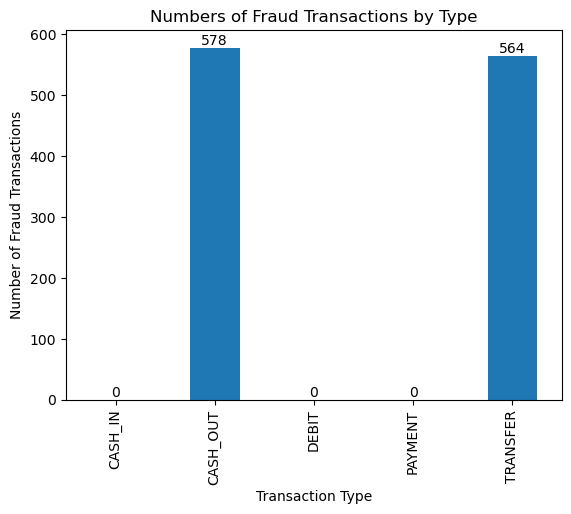

In [34]:
num_fraud_type= df.groupby("type")["isFraud"].sum()
numfraud=num_fraud_type.plot.bar()
plt.title("Numbers of Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
numfraud.bar_label(numfraud.containers[0])
plt.show()

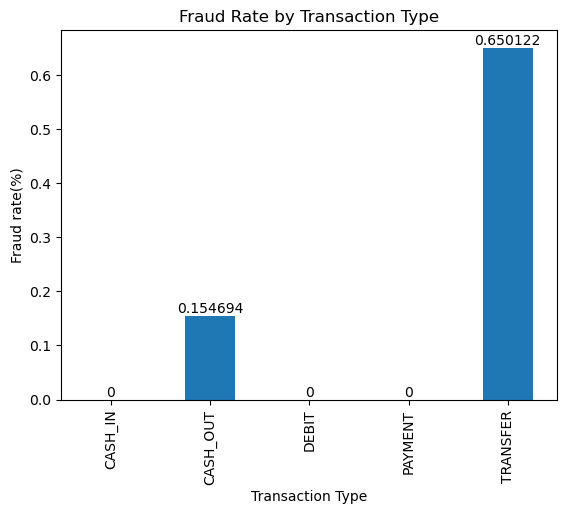

In [35]:
fraud_by_rate= df.groupby("type")["isFraud"].mean()*100
pt=fraud_by_rate.plot.bar()
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud rate(%)")
pt.bar_label(pt.containers[0])
plt.show()

Based on the plot, we can clearly see that most fraudulent transactions occur in the **Cash out** and **Transfer** categories. Among all fraud cases, **Transfer** transactions have the highest percentage with **65%** of fraudulent activity.

In [36]:
print(df.groupby("isFraud")["amount"].mean().map("{:,.2f}".format))

isFraud
0      157,539.66
1    1,192,628.93
Name: amount, dtype: object


In [37]:
print(df.groupby("isFraud")["amount"].median())

isFraud
0     76214.97
1    353179.45
Name: amount, dtype: float64


In [38]:
print(df.groupby('isFraud')['amount'].max())

isFraud
0     6419835.27
1    10000000.00
Name: amount, dtype: float64


These three values suggest that fraudulent transactions have **larger amounts of money** compared to regular transactions.

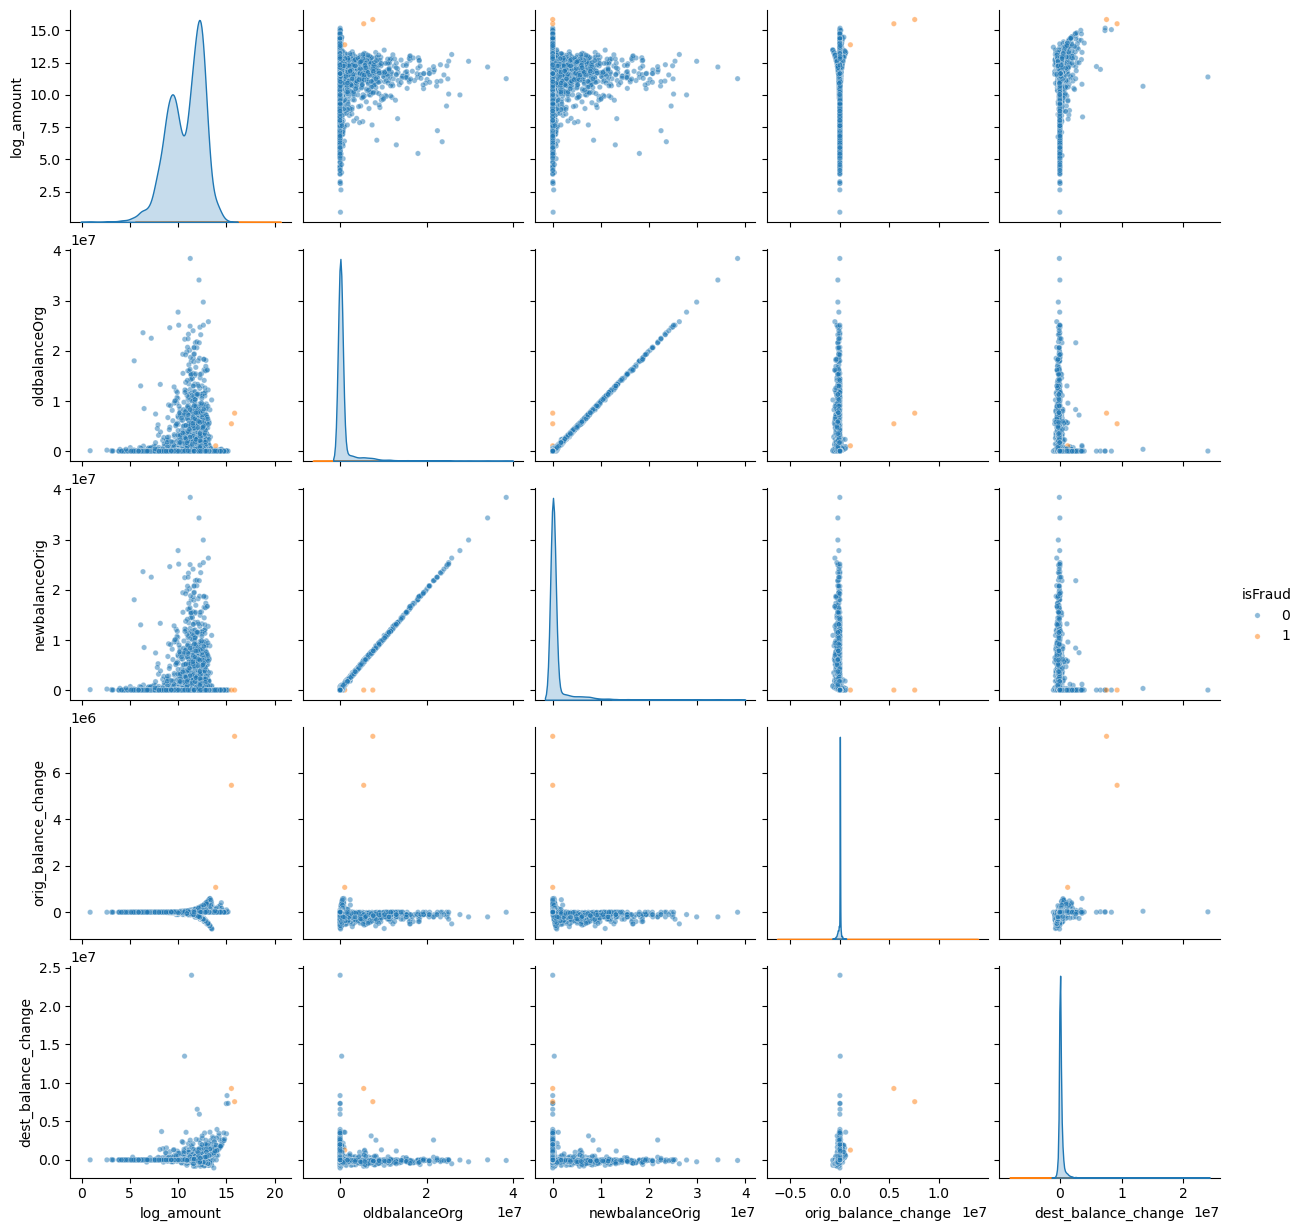

In [39]:
df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["log_amount"] = np.log1p(df["amount"])
sample_df = df.sample(n=5000, random_state=42)
pairplot_cols = ["log_amount","oldbalanceOrg","newbalanceOrig","orig_balance_change","dest_balance_change","isFraud"]
sns.pairplot(sample_df[pairplot_cols],hue="isFraud",diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.show()

In [41]:
int((df['orig_balance_change']<0).sum())

221805

In [42]:
int((df['dest_balance_change']<0).sum())

203566

In [43]:
df= df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis=1)

In [44]:
df = pd.get_dummies(df, columns=["type"])

In [45]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_change,dest_balance_change,log_amount,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,9.194276,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,7.531166,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,5.204007,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0,5.204007,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,9.364703,False,False,False,True,False


### Split data into training and test sets

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
x=df.drop("isFraud",axis=1)
y=df["isFraud"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

### Decision Tree

In [47]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    314230
           1       0.83      0.79      0.81       343

    accuracy                           1.00    314573
   macro avg       0.91      0.89      0.90    314573
weighted avg       1.00      1.00      1.00    314573



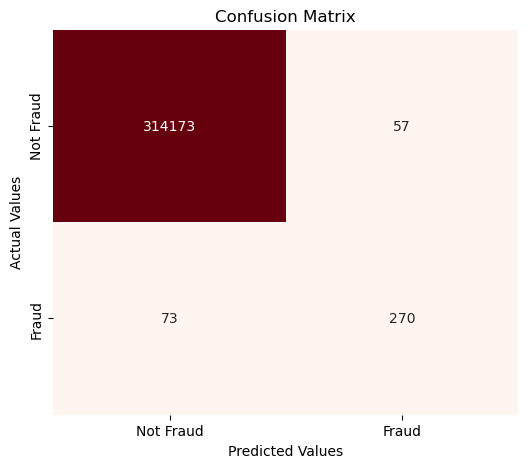

In [49]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Reds",cbar=False,xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")
plt.show()

### Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
log_model = Pipeline([("scaler",StandardScaler()),('model',LogisticRegression(max_iter=1000,class_weight="balanced"))])
log_model.fit(x_train,y_train)
y_pred_log = log_model.predict(x_test)

In [51]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    314230
           1       0.02      0.96      0.04       343

    accuracy                           0.94    314573
   macro avg       0.51      0.95      0.50    314573
weighted avg       1.00      0.94      0.97    314573



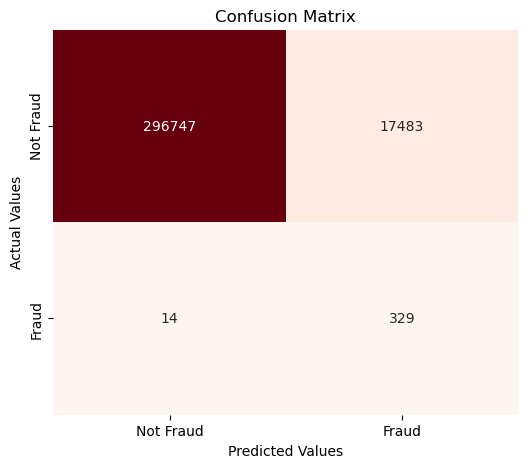

In [52]:
cm_LR = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_LR,annot=True,fmt="d",cmap="Reds",cbar=False,xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")
plt.show()

### XGBoost

In [53]:
from xgboost import XGBClassifier
neg = y_train.value_counts()[0]
pos = y_train.value_counts()[1]
scale_pos_weight = neg / pos
xgb_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, scale_pos_weight=scale_pos_weight ,eval_metric="logloss", random_state=42)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

In [54]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    314230
           1       0.24      0.95      0.39       343

    accuracy                           1.00    314573
   macro avg       0.62      0.97      0.69    314573
weighted avg       1.00      1.00      1.00    314573



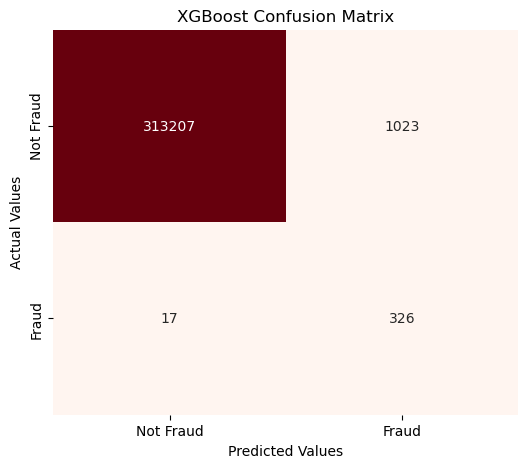

In [55]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb, annot=True, fmt="d", cmap="Reds", 
    cbar=False,xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("XGBoost Confusion Matrix")
plt.show()

### LightGBM

In [56]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1, num_leaves=31,
                            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=42)
lgbm_model.fit(x_train, y_train)
y_pred_lgbm = lgbm_model.predict(x_test)

[LightGBM] [Info] Number of positive: 799, number of negative: 733203
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2122
[LightGBM] [Info] Number of data points in the train set: 734002, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001089 -> initscore=-6.821817
[LightGBM] [Info] Start training from score -6.821817
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No fur

In [57]:
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    314230
           1       0.01      0.88      0.03       343

    accuracy                           0.93    314573
   macro avg       0.51      0.91      0.49    314573
weighted avg       1.00      0.93      0.96    314573



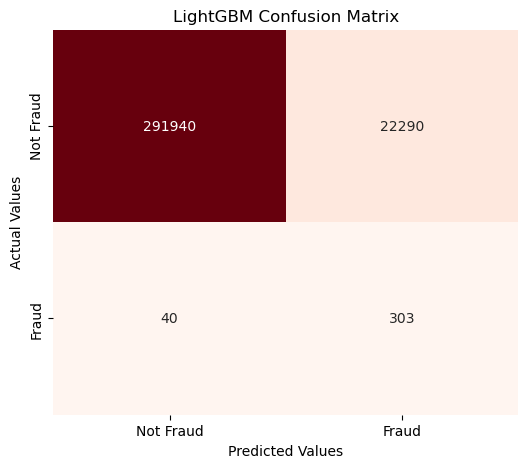

In [58]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lgbm, annot=True, fmt="d", cmap="Reds", cbar=False, xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("LightGBM Confusion Matrix")
plt.show()

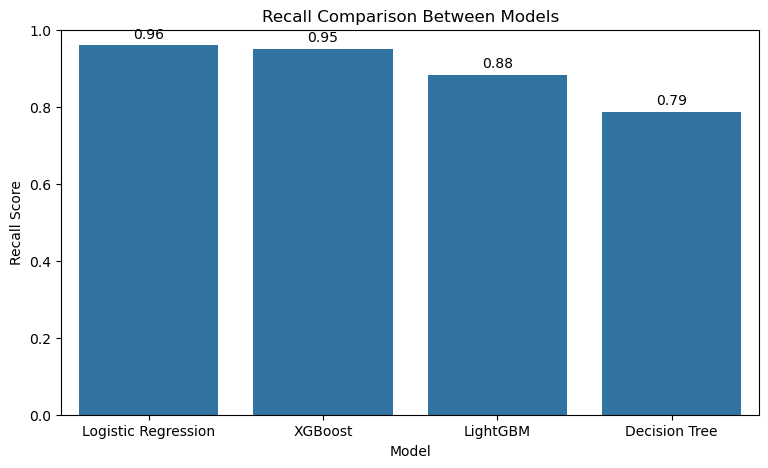

In [59]:
from sklearn.metrics import recall_score
recall_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Decision Tree"
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred)
    ]
})
recall_comparison
plt.figure(figsize=(9, 5))

ay= sns.barplot(
    data=recall_comparison,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison Between Models")
plt.ylabel("Recall Score")
plt.xlabel("Model")
plt.ylim(0, 1)
for container in ay.containers:
    ay.bar_label(container, fmt="%.2f", padding=3)
plt.show()

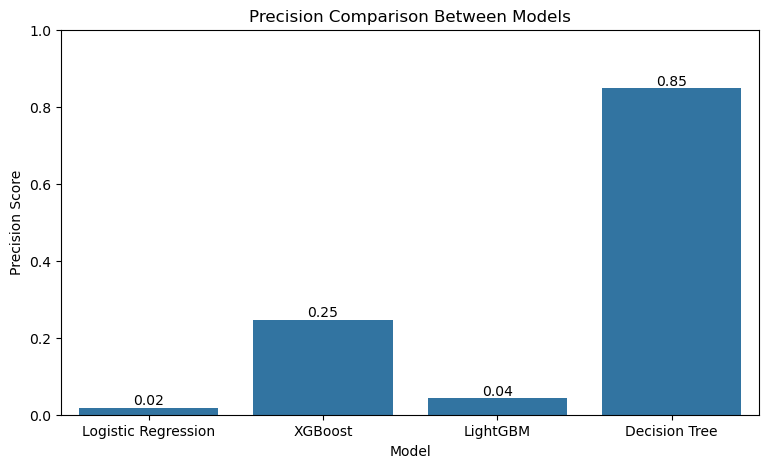

In [111]:
from sklearn.metrics import precision_score
precision_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Decision Tree"
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred)
    ]
})
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=precision_comparison,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison Between Models")
plt.ylabel("Precision Score")
plt.xlabel("Model")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

In [60]:
accuracy_comparision = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ]
})

accuracy_comparision

,Model,Accuracy
0,Logistic Regression,0.944379
1,Decision Tree,0.999587
2,XGBoost,0.996694
3,LightGBM,0.929015


### Summary
* After training the four models, **Decision Tree**  and **XGBoost** performed the best overall compared to the other models.
* **The Decision Tree** model gave a good balance between precision and recall. Its recall score was **0.79**, which means it was able to catch many of the actual fraud cases. Its precision score was **0.85**, which means that when the model predicted a transaction as fraud, it was usually correct. This shows that the Decision Tree model does not miss too many fraud cases and also does not create too many false alarms.
* **XGBoost**, on the other hand, had a higher accuracy and a very high recall score of **0.95**. This means it was better at finding fraud cases and missed fewer fraud transactions. However, its precision score was only **0.25**, meaning many of the transactions it predicted as fraud were actually normal transactions. So, XGBoost catches more fraud, but it also creates more false alarms.
* Overall, users can choose either model based on their needs. If the main goal is to catch as many fraud cases as possible, then XGBoost would be a good choice because it has higher recall. However, if users want to reduce false alarms and avoid marking too many normal transactions as fraud, then the Decision Tree model would be more helpful because it gives a better balance between precision and recall.